# combo_chart function demo

In [1]:
# Import libraries
from process_improvement.charts.combo_chart import combo_chart
from process_improvement.charts.utils import ComboChartConfig

from process_improvement.data_loader import list_example_files, load_example_data

%matplotlib inline

## Get data

In [2]:
# List example files
list_example_files()

['18650_battery_cells',
 '2170_battery_cell',
 'automated_manufacturing_part_lengths',
 'eight_machine_manufacturing_process',
 'milikans_electron_charge_observations',
 'monthly_united_states_trade_deficits_2024',
 'OP200_weekly_first_pass_yield',
 'quarterly_sales_by_region',
 'shewharts_resistance_measurements',
 'software_verification_death_to_birth_rates',
 'software_verification_resistance_measurement',
 'wafer_assembly_part_placement']

In [3]:
# Create dataframe
df = load_example_data("shewharts_resistance_measurements")

initial_df = df[df['Stage'] == 'Initial']

df.head()

,Stage,Units,Value,Resistance
0,Initial,megohms,1.0,5045.0
1,Initial,megohms,2.0,4350.0
2,Initial,megohms,3.0,4350.0
3,Initial,megohms,4.0,3975.0
4,Initial,megohms,5.0,4290.0


## Specification Limit

In [4]:
USL = 5295
LSL = 3395
tolerance = USL - LSL
target = LSL + (tolerance/2)

## Configuration and combo chart

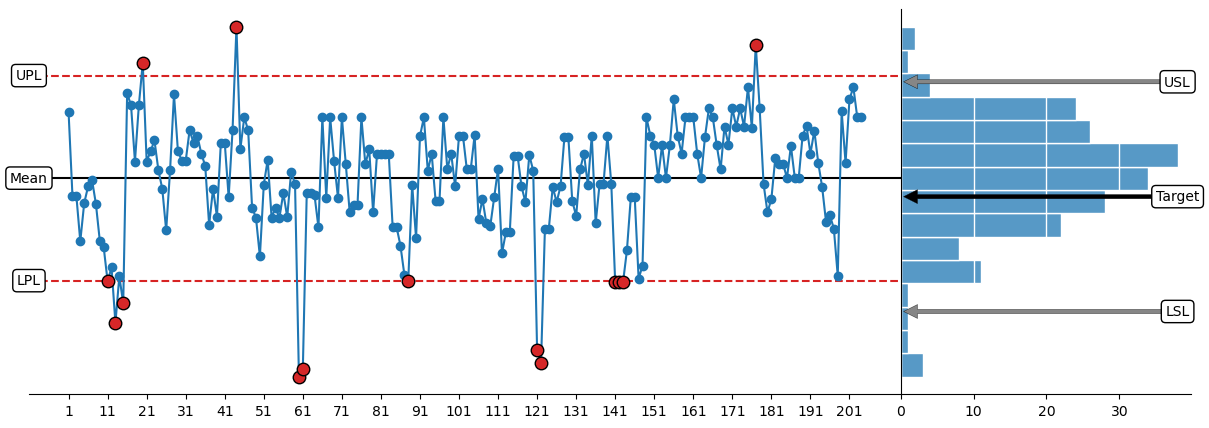

In [16]:
# Configuration
config = ComboChartConfig(
    figsize=(15,5),
    tickinterval=10,
    show_capabilities=False,
    show_limit_values=False
)

# Create XmR chart
results = combo_chart(
    df=initial_df,
    values_column='Resistance',
    xchart_labels_column='Value',
    USL=USL,
    LSL=LSL,
    config=config
)

## Show process statistics

In [10]:
# Show statistics
round(results.stats_df, 2)

,Characterization,Cp,Cpk,Pp,Ppk,Mean,Std Dev (s),Sigma(X),DNS,Tolerance,Target,USL,LSL
0,Unpredictable,1.12,0.94,0.68,0.57,4498.18,466.39,282.63,796.82,1900,4345.0,5295,3395


## Alternate configuration and combo chart

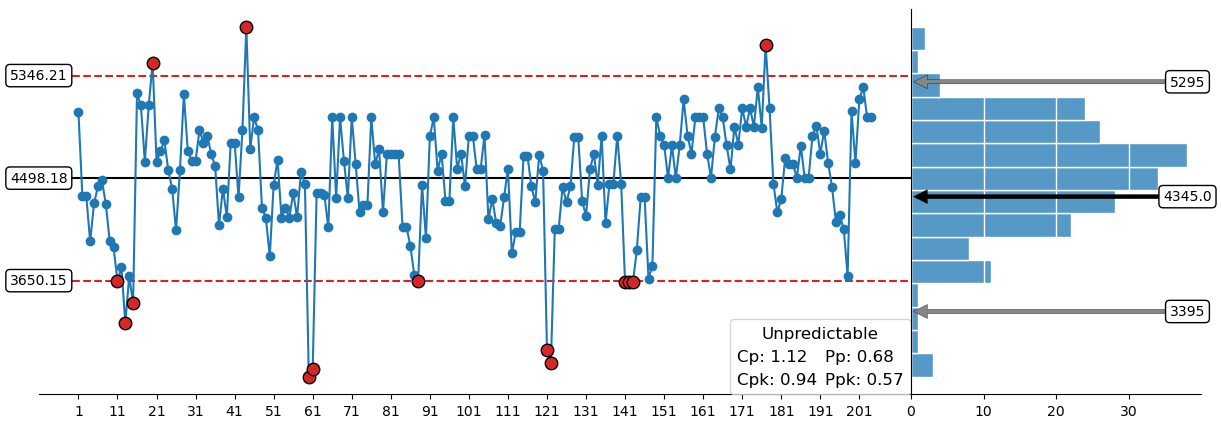

In [18]:
# Configuration
config2 = ComboChartConfig(
    figsize=(15,5),
    tickinterval=10,
    show_capabilities=True,
    show_limit_values=True
)

# Create XmR chart
results2 = combo_chart(
    df=initial_df,
    values_column='Resistance',
    xchart_labels_column='Value',
    USL=USL,
    LSL=LSL,
    config=config2
)